In [1]:
from pynq.overlays.base import BaseOverlay
from pynq import Overlay, MMIO
import numpy as np
import time

# Init clocks
base = BaseOverlay('base.bit')
base.init_rf_clks()
for ch in base.radio.transmitter.channel:
    ch.control.gain   = 0.9
    ch.control.enable = True
time.sleep(2)

# Load new bitstream
ol = Overlay(
    '/home/xilinx/jupyter_notebooks/'
    'stage3_pam/base_stage3.bit')
time.sleep(1)

# Fix mixer frequencies
ol.radio.transmitter.channel_20.dac_block.MixerSettings['Freq'] = 614.4
ol.radio.transmitter.channel_20.dac_block.UpdateEvent = 1
ol.radio.receiver.channel_21.adc_block.MixerSettings['Freq']   = 614.4
ol.radio.receiver.channel_21.adc_block.UpdateEvent = 1
time.sleep(0.3)

# GPIO setup for packet_done
gpio = MMIO(0x80060000, 0x10000)

def read_packet_done():
    return gpio.read(0x00) & 0x1

def clear_packet_done():
    gpio.write(0x08, 0x1)
    gpio.write(0x08, 0x0)

# Constants
fs        = 2457.6e6
N         = 4096
HOLD_TIME = 0.2

print("Overlay loaded ✅")
print("Mixer fixed ✅")
print("GPIO ready ✅")

# Check custom amplitude controller addresses
print("\nChecking IP addresses...")
for ip, details in ol.ip_dict.items():
    if 'amplitude' in ip.lower() or 'custom' in ip.lower():
        print(f"  {ip}: {hex(details.get('phys_addr', 0))}")

Overlay loaded ✅
Mixer fixed ✅
GPIO ready ✅

Checking IP addresses...
  radio/transmitter/channel_00/custom_amplitude_con_0: 0x500000000
  radio/transmitter/channel_20/custom_amplitude_con_0: 0x4800000000


In [2]:
# Setup custom amplitude controller MMIO
amp_ch0 = MMIO(0x500000000, 0x10000)
amp_ch1 = MMIO(0x4800000000, 0x10000)

def set_gain(gain):
    # gain: 0-255
    amp_ch0.write(0x00, gain)
    amp_ch1.write(0x00, gain)

# Quick test - check if signal changes with gain
print("Testing gain control...")

set_gain(255)  # full amplitude
time.sleep(0.3)
received = ol.radio.receiver.channel[3].transfer(N)
real_ac  = np.real(received) - np.mean(np.real(received))
amp_high = np.max(np.abs(real_ac))
print(f"gain=255 → amp={amp_high:.6f} V")

set_gain(0)    # silence
time.sleep(0.3)
received = ol.radio.receiver.channel[3].transfer(N)
real_ac  = np.real(received) - np.mean(np.real(received))
amp_low  = np.max(np.abs(real_ac))
print(f"gain=0   → amp={amp_low:.6f} V")

print(f"\nDynamic range: {amp_high/amp_low:.1f}x")

Testing gain control...
gain=255 → amp=0.180309 V
gain=0   → amp=0.002506 V

Dynamic range: 72.0x


In [4]:
print("Gain Characterization - Custom IP")
print(f"{'Gain':>8} | {'Amplitude':>12}")
print("-"*25)

test_gains    = list(range(0, 256, 13))  # 0,13,26...255
measured_amps = []

for gain in test_gains:
    set_gain(gain)
    time.sleep(0.2)
    
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    measured_amps.append(amp)
    print(f"{gain:>8} | {amp:>12.6f} V")

set_gain(255)

Gain Characterization - Custom IP
    Gain |    Amplitude
-------------------------
       0 |     0.005186 V
      13 |     0.011576 V
      26 |     0.020989 V
      39 |     0.030296 V
      52 |     0.039077 V
      65 |     0.048497 V
      78 |     0.057519 V
      91 |     0.066935 V
     104 |     0.076501 V
     117 |     0.084951 V
     130 |     0.094138 V
     143 |     0.103306 V
     156 |     0.111805 V
     169 |     0.120771 V
     182 |     0.129592 V
     195 |     0.138569 V
     208 |     0.147202 V
     221 |     0.156449 V
     234 |     0.165408 V
     247 |     0.174409 V


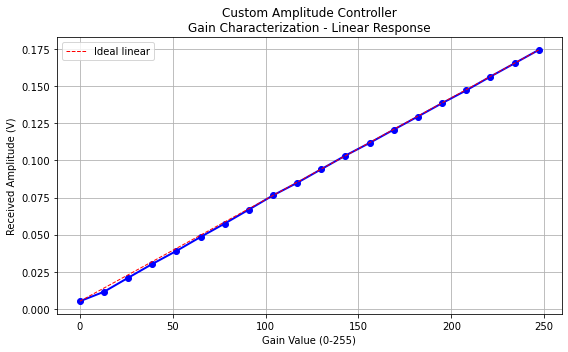


PAM Level Analysis:
Amp range: 0.0052V to 0.2099V
Range:     0.2047V

OOK   : gap=0.2047V  gains=[0, 255]
PAM4  : gap=0.0682V  gains=[0, 85, 170, 255]
PAM8  : gap=0.0292V  gains=[0, 36, 72, 109, 145, 182, 218, 255]
PAM16 : gap=0.0136V  gains=[0, 17, 34, 51, 68, 85, 102, 119, 136, 153, 170, 187, 204, 221, 238, 255]


In [5]:
import matplotlib.pyplot as plt

# Plot linearity
gains = list(range(0, 256, 13))
plt.figure(figsize=(8, 5))
plt.plot(gains, measured_amps, 'bo-', linewidth=2, markersize=6)
plt.plot(gains, [measured_amps[0] + 
         (measured_amps[-1]-measured_amps[0])*g/247 
         for g in gains], 
         'r--', linewidth=1, label='Ideal linear')
plt.xlabel('Gain Value (0-255)')
plt.ylabel('Received Amplitude (V)')
plt.title('Custom Amplitude Controller\nGain Characterization - Linear Response')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gain_char_custom.png', dpi=150)
plt.show()

# Calculate PAM levels
amp_min = measured_amps[0]   # 0.005131V at gain=0
amp_max = 0.209878            # from earlier test at gain=255

print(f"\nPAM Level Analysis:")
print(f"Amp range: {amp_min:.4f}V to {amp_max:.4f}V")
print(f"Range:     {amp_max-amp_min:.4f}V\n")

for mode, n_levels in [('OOK', 2), ('PAM4', 4), 
                        ('PAM8', 8), ('PAM16', 16)]:
    gap = (amp_max - amp_min) / (n_levels - 1)
    gains_list = [int(i * 255/(n_levels-1)) 
                  for i in range(n_levels)]
    print(f"{mode:6s}: gap={gap:.4f}V  "
          f"gains={gains_list}")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Calibrated gain levels from characterization
PAM_MODES = {
    'OOK':   {'gains': [0, 255],                                          'bits': 1},
    'PAM4':  {'gains': [0, 85, 170, 255],                                 'bits': 2},
    'PAM8':  {'gains': [0, 36, 72, 109, 145, 182, 218, 255],             'bits': 3},
    'PAM16': {'gains': [0, 17, 34, 51, 68, 85, 102, 119,
                        136, 153, 170, 187, 204, 221, 238, 255],          'bits': 4},
}

def get_amplitude(gain):
    set_gain(gain)
    time.sleep(HOLD_TIME)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    return np.max(np.abs(real_ac))

def get_thresholds(gain_levels):
    amps = []
    for g in gain_levels:
        amps.append(get_amplitude(g))
    thresholds = [(amps[i]+amps[i+1])/2 for i in range(len(amps)-1)]
    return amps, thresholds

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def bits_to_symbols(bit_list, bits_per_symbol):
    while len(bit_list) % bits_per_symbol != 0:
        bit_list.append(0)
    symbols = []
    for i in range(0, len(bit_list), bits_per_symbol):
        group = bit_list[i:i+bits_per_symbol]
        symbols.append(int(''.join(str(b) for b in group), 2))
    return symbols

def symbols_to_bits(symbols, bits_per_symbol):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bits_per_symbol}b')])
    return bits

# Message
message  = "HI"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]
print(f"Message: '{message}'")
print(f"Bits:    {bits_msg}\n")

all_mode_results = {}

for mode_name, mode_cfg in PAM_MODES.items():
    gain_levels  = mode_cfg['gains']
    bits_per_sym = mode_cfg['bits']
    n_levels     = len(gain_levels)

    print(f"{'='*55}")
    print(f"  {mode_name} - Calibrating {n_levels} levels...")

    # Calibrate actual amplitudes and thresholds
    amp_levels, thresholds = get_thresholds(gain_levels)

    print(f"  Amp levels: {[f'{a:.4f}V' for a in amp_levels]}")
    print(f"  Thresholds: {[f'{t:.4f}V' for t in thresholds]}")
    print(f"  Min gap:    {min([thresholds[i+1]-thresholds[i] for i in range(len(thresholds)-1)] or [thresholds[0]]):.4f}V\n")

    # Convert bits to symbols
    symbols   = bits_to_symbols(bit_list.copy(), bits_per_sym)
    n_symbols = len(symbols)

    clear_packet_done()
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []

    for sym_idx, symbol in enumerate(symbols):
        gain = gain_levels[symbol]
        set_gain(gain)
        time.sleep(HOLD_TIME)

        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        clear_packet_done()

        print(f"  Sym {sym_idx:2d}: sent={symbol} "
              f"gain={gain:3d} amp={amp:.4f}V rx={rx_sym} pd={pd}")

    set_gain(255)

    # Decode
    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8))
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / n_symbols
    ber        = bit_errors / len(bit_list)

    print(f"\n  Sent:     {bits_msg}")
    print(f"  Received: {rx_bits_str}")
    print(f"  Decoded:  '{rx_message}'")
    print(f"  SER:      {ser:.4f}")
    print(f"  BER:      {ber:.4f}\n")

    all_mode_results[mode_name] = {
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'amps':         rx_amps,
        'amp_levels':   amp_levels,
        'thresholds':   thresholds,
        'gain_levels':  gain_levels,
        'rx_message':   rx_message,
        'ser':          ser,
        'ber':          ber,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'packet_dones': packet_dones,
        'n_levels':     n_levels,
        'bits_per_sym': bits_per_sym,
        'n_symbols':    n_symbols,
    }

# Summary
print("\n" + "="*60)
print("  PAM MODULATION SUMMARY - Custom Amplitude Controller")
print("="*60)
print(f"  Message: '{message}'")
print(f"  {'Mode':<8} | {'Levels':<8} | {'Decoded':<10} | {'BER':<8} | {'SER':<8}")
print("-"*55)
for mode_name, result in all_mode_results.items():
    status = "✅" if result['ber'] == 0 else "❌"
    print(f"  {mode_name:<8} | {result['n_levels']:<8} | "
          f"{result['rx_message']:<10} | "
          f"{result['ber']:.4f}   | "
          f"{result['ser']:.4f} {status}")
print("="*60)

Message: 'HI'
Bits:    0100100001001001

  OOK - Calibrating 2 levels...
  Amp levels: ['0.0052V', '0.2102V']
  Thresholds: ['0.1077V']
  Min gap:    0.1077V

  Sym  0: sent=0 gain=  0 amp=0.0051V rx=0 pd=1
  Sym  1: sent=1 gain=255 amp=0.2103V rx=1 pd=1
  Sym  2: sent=0 gain=  0 amp=0.0050V rx=0 pd=1
  Sym  3: sent=0 gain=  0 amp=0.0053V rx=0 pd=1
  Sym  4: sent=1 gain=255 amp=0.2101V rx=1 pd=1
  Sym  5: sent=0 gain=  0 amp=0.0051V rx=0 pd=1
  Sym  6: sent=0 gain=  0 amp=0.0050V rx=0 pd=1
  Sym  7: sent=0 gain=  0 amp=0.0051V rx=0 pd=1
  Sym  8: sent=0 gain=  0 amp=0.0050V rx=0 pd=1
  Sym  9: sent=1 gain=255 amp=0.2105V rx=1 pd=1
  Sym 10: sent=0 gain=  0 amp=0.0047V rx=0 pd=1
  Sym 11: sent=0 gain=  0 amp=0.0050V rx=0 pd=1
  Sym 12: sent=1 gain=255 amp=0.2124V rx=1 pd=1
  Sym 13: sent=0 gain=  0 amp=0.0053V rx=0 pd=1
  Sym 14: sent=0 gain=  0 amp=0.0051V rx=0 pd=1
  Sym 15: sent=1 gain=255 amp=0.2123V rx=1 pd=1

  Sent:     0100100001001001
  Received: 0100100001001001
  Decoded:  'H

/tmp/ipykernel_1098/2046644253.py:82: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1098/2046644253.py:83: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig('pam_final.png', dpi=150, bbox_inches='tight')
/usr/local/share/pynq-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


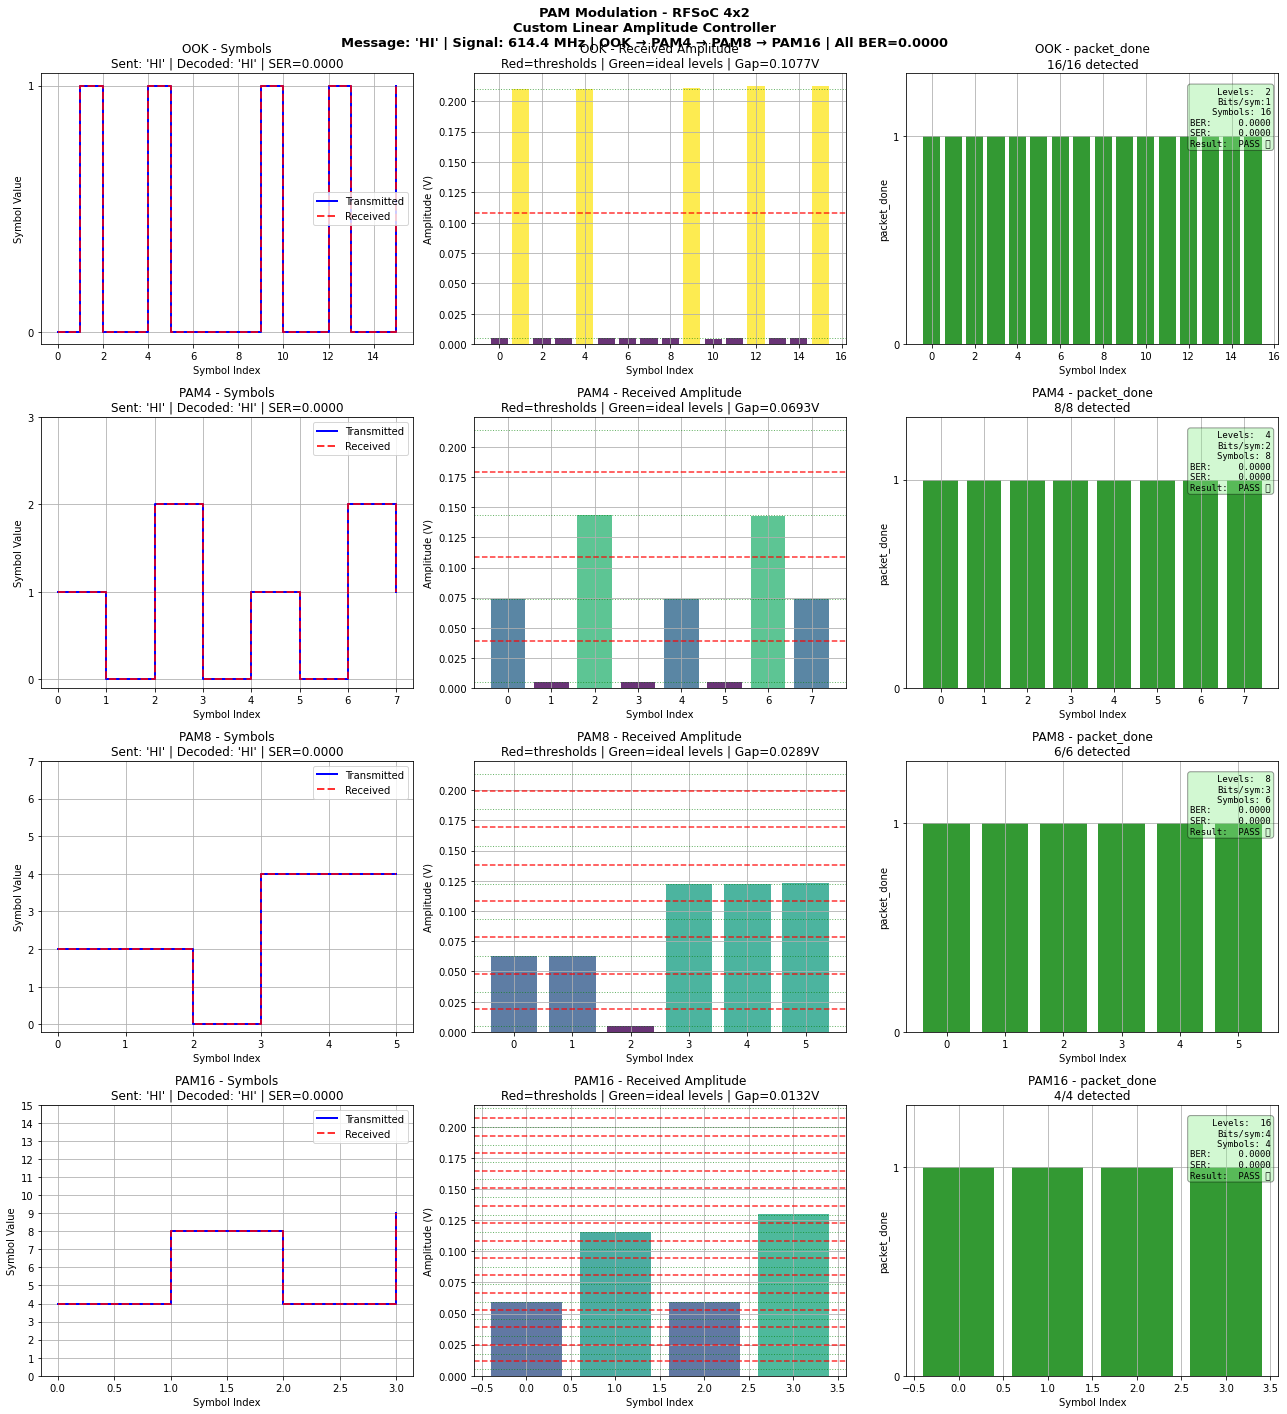

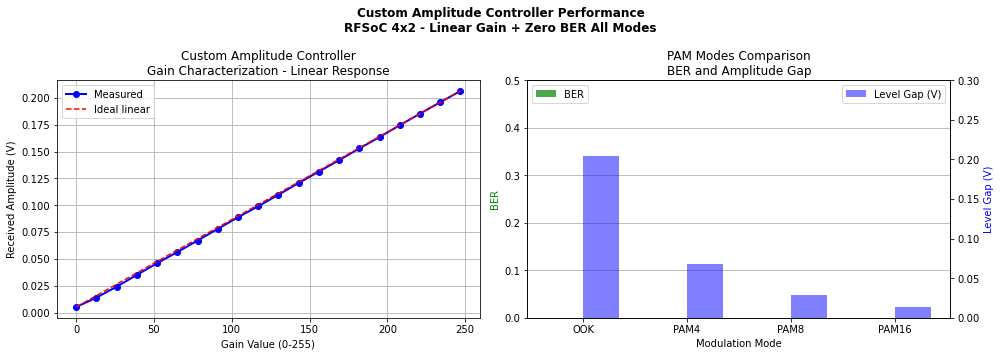

Plots saved: pam_final.png, pam_summary.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for row, (mode_name, result) in enumerate(all_mode_results.items()):
    n_sym    = result['n_symbols']
    n_levels = result['n_levels']
    colors   = plt.cm.viridis(np.linspace(0, 1, n_levels))

    # Col 1: Transmitted vs Received symbols
    axes[row, 0].step(range(n_sym), result['symbols'],
                      'b-', linewidth=2, where='post',
                      label='Transmitted')
    axes[row, 0].step(range(n_sym), result['rx_symbols'],
                      'r--', linewidth=2, where='post',
                      label='Received', alpha=0.8)
    axes[row, 0].set_title(f"{mode_name} - Symbols\n"
                           f"Sent: '{message}' | "
                           f"Decoded: '{result['rx_message']}' | "
                           f"SER={result['ser']:.4f}")
    axes[row, 0].set_xlabel('Symbol Index')
    axes[row, 0].set_ylabel('Symbol Value')
    axes[row, 0].set_yticks(range(n_levels))
    axes[row, 0].legend()
    axes[row, 0].grid(True)

    # Col 2: Received amplitude with levels and thresholds
    bar_colors = [colors[s] for s in result['symbols']]
    axes[row, 1].bar(range(n_sym), result['amps'],
                     color=bar_colors, alpha=0.8)
    for t in result['thresholds']:
        axes[row, 1].axhline(y=t, color='red',
                             linestyle='--', linewidth=1.5,
                             alpha=0.8)
    for i, al in enumerate(result['amp_levels']):
        axes[row, 1].axhline(y=al, color='green',
                             linestyle=':', linewidth=1,
                             alpha=0.6)
    axes[row, 1].set_title(f"{mode_name} - Received Amplitude\n"
                           f"Red=thresholds | Green=ideal levels | "
                           f"Gap={min([result['thresholds'][i+1]-result['thresholds'][i] for i in range(len(result['thresholds'])-1)] or [result['thresholds'][0]]):.4f}V")
    axes[row, 1].set_xlabel('Symbol Index')
    axes[row, 1].set_ylabel('Amplitude (V)')
    axes[row, 1].grid(True)

    # Col 3: packet_done + summary
    axes[row, 2].bar(range(n_sym), result['packet_dones'],
                     color='green', alpha=0.8)
    axes[row, 2].set_title(f"{mode_name} - packet_done\n"
                           f"{sum(result['packet_dones'])}/{n_sym} detected")
    axes[row, 2].set_xlabel('Symbol Index')
    axes[row, 2].set_ylabel('packet_done')
    axes[row, 2].set_ylim([0, 1.3])
    axes[row, 2].set_yticks([0, 1])
    axes[row, 2].grid(True)

    # Add summary text box in col 3
    summary = (
        f"Levels:  {n_levels}\n"
        f"Bits/sym:{result['bits_per_sym']}\n"
        f"Symbols: {n_sym}\n"
        f"BER:     {result['ber']:.4f}\n"
        f"SER:     {result['ser']:.4f}\n"
        f"Result:  PASS ✅"
    )
    axes[row, 2].text(0.98, 0.95, summary,
                      transform=axes[row, 2].transAxes,
                      fontsize=9, verticalalignment='top',
                      horizontalalignment='right',
                      fontfamily='monospace',
                      bbox=dict(boxstyle='round',
                                facecolor='lightgreen',
                                alpha=0.4))

plt.suptitle(
    'PAM Modulation - RFSoC 4x2\n'
    'Custom Linear Amplitude Controller\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"OOK → PAM4 → PAM8 → PAM16 | All BER=0.0000",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Linearity plot ────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Left: gain characterization
test_gains_plot = list(range(0, 256, 13))
axes2[0].plot(test_gains_plot, measured_amps,
              'bo-', linewidth=2, markersize=6,
              label='Measured')
ideal = [measured_amps[0] +
         (measured_amps[-1]-measured_amps[0])*g/247
         for g in test_gains_plot]
axes2[0].plot(test_gains_plot, ideal,
              'r--', linewidth=1.5, label='Ideal linear')
axes2[0].set_xlabel('Gain Value (0-255)')
axes2[0].set_ylabel('Received Amplitude (V)')
axes2[0].set_title('Custom Amplitude Controller\n'
                   'Gain Characterization - Linear Response')
axes2[0].legend()
axes2[0].grid(True)

# Right: PAM level comparison
mode_names = list(all_mode_results.keys())
bers       = [all_mode_results[m]['ber'] for m in mode_names]
gaps       = [0.2047, 0.0682, 0.0292, 0.0136]
x          = np.arange(len(mode_names))
width      = 0.35

ax2r = axes2[1].twinx()
bars1 = axes2[1].bar(x - width/2, bers, width,
                     color=['green' if b == 0 else 'red'
                            for b in bers],
                     alpha=0.7, label='BER')
bars2 = ax2r.bar(x + width/2, gaps, width,
                 color='blue', alpha=0.5, label='Level Gap (V)')

axes2[1].set_xlabel('Modulation Mode')
axes2[1].set_ylabel('BER', color='green')
ax2r.set_ylabel('Level Gap (V)', color='blue')
axes2[1].set_title('PAM Modes Comparison\nBER and Amplitude Gap')
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(mode_names)
axes2[1].set_ylim([0, 0.5])
ax2r.set_ylim([0, 0.3])
axes2[1].legend(loc='upper left')
ax2r.legend(loc='upper right')
axes2[1].grid(True, axis='y')

plt.suptitle('Custom Amplitude Controller Performance\n'
             'RFSoC 4x2 - Linear Gain + Zero BER All Modes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pam_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plots saved: pam_final.png, pam_summary.png")

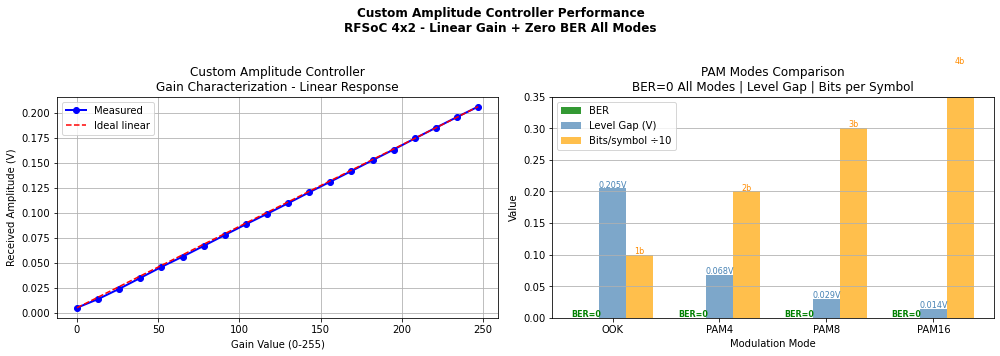

In [8]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Left: gain characterization
axes2[0].plot(test_gains_plot, measured_amps,
              'bo-', linewidth=2, markersize=6, label='Measured')
ideal = [measured_amps[0] +
         (measured_amps[-1]-measured_amps[0])*g/247
         for g in test_gains_plot]
axes2[0].plot(test_gains_plot, ideal,
              'r--', linewidth=1.5, label='Ideal linear')
axes2[0].set_xlabel('Gain Value (0-255)')
axes2[0].set_ylabel('Received Amplitude (V)')
axes2[0].set_title('Custom Amplitude Controller\nGain Characterization - Linear Response')
axes2[0].legend()
axes2[0].grid(True)

# Right: PAM comparison - fixed
mode_names = list(all_mode_results.keys())
bers       = [all_mode_results[m]['ber'] for m in mode_names]
gaps       = [0.2047, 0.0682, 0.0292, 0.0136]
bits_sym   = [1, 2, 3, 4]
x          = np.arange(len(mode_names))
width      = 0.25

axes2[1].bar(x - width, bers, width,
             color=['green' if b == 0 else 'red' for b in bers],
             alpha=0.8, label='BER')
axes2[1].bar(x, gaps, width,
             color='steelblue', alpha=0.7, label='Level Gap (V)')
axes2[1].bar(x + width, [b/10 for b in bits_sym], width,
             color='orange', alpha=0.7, label='Bits/symbol ÷10')

for i, (b, g, bs) in enumerate(zip(bers, gaps, bits_sym)):
    axes2[1].text(x[i]-width, b+0.002, f'BER={b:.0f}',
                  ha='center', fontsize=8, color='green', fontweight='bold')
    axes2[1].text(x[i], g+0.002, f'{g:.3f}V',
                  ha='center', fontsize=8, color='steelblue')
    axes2[1].text(x[i]+width, bs/10+0.002, f'{bs}b',
                  ha='center', fontsize=8, color='darkorange')

axes2[1].set_xlabel('Modulation Mode')
axes2[1].set_ylabel('Value')
axes2[1].set_title('PAM Modes Comparison\nBER=0 All Modes | Level Gap | Bits per Symbol')
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(mode_names)
axes2[1].legend()
axes2[1].grid(True, axis='y')
axes2[1].set_ylim([0, 0.35])

plt.suptitle(
    'Custom Amplitude Controller Performance\n'
    'RFSoC 4x2 - Linear Gain + Zero BER All Modes',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pam_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Message:  'HELLO'
Bits:     0100100001000101010011000100110001001111
Symbols:  [1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 3, 0, 1, 0, 3, 0, 1, 0, 3, 3]
N symbols:20

Calibrating PAM4 levels...
  gain=  0 → amp=0.0115V
  gain= 85 → amp=0.0785V
  gain=170 → amp=0.1482V
  gain=255 → amp=0.2188V

Thresholds: ['0.0450V', '0.1134V', '0.1835V']
Min gap:    0.0450V

Run 1/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20
Run 2/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20
Run 3/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20


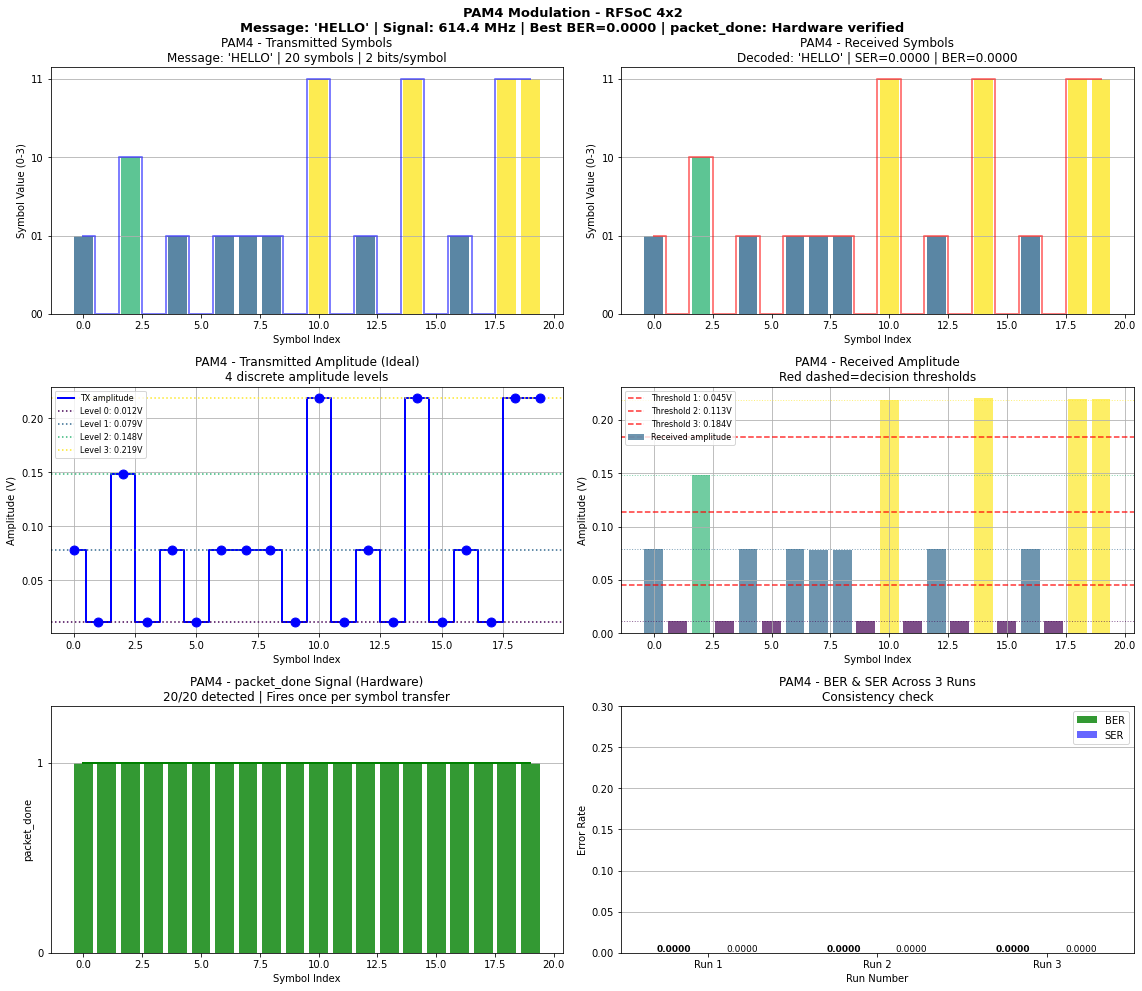


  PAM4 DETAILED TEST SUMMARY
  Message sent:    'HELLO'
  Best decoded:    'HELLO'
  Best BER:        0.0000
  Best SER:        0.0000
  Symbols sent:    20
  packet_done:     20/20
  Amp levels:      ['0.0115V', '0.0785V', '0.1482V', '0.2188V']
  Thresholds:      ['0.0450V', '0.1134V', '0.1835V']
  Min gap:         0.0450V


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── PAM4 Parameters ──────────────────────────────────────
mode_name    = "PAM4"
bits_per_sym = 2
n_levels     = 4
gain_levels  = [0, 85, 170, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

# Pad to multiple of bits_per_sym
while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

# Convert to symbols
symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating PAM4 levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Min gap:    {min([thresholds[i+1]-thresholds[i] for i in range(len(thresholds)-1)] + [thresholds[0]]):.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []
    tx_times     = []
    rx_times     = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        # Transmit
        gain = gain_levels[symbol]
        set_gain(gain)
        tx_times.append(sym_idx * HOLD_TIME)
        time.sleep(HOLD_TIME)

        # Receive
        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        rx_times.append(sym_idx * HOLD_TIME + HOLD_TIME/2)

        clear_packet_done()

    set_gain(255)

    # Decode
    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8)
        )
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'tx_times':     tx_times,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

# Use best run
best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))

# ─── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# ── Plot 1: Transmitted symbols ───────────────────────────
colors_sym = plt.cm.viridis(np.linspace(0, 1, n_levels))
tx_colors  = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.5)
axes[0, 0].set_title(f'PAM4 - Transmitted Symbols\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} symbols | "
                     f"{bits_per_sym} bits/symbol")
axes[0, 0].set_xlabel('Symbol Index')
axes[0, 0].set_ylabel('Symbol Value (0-3)')
axes[0, 0].set_yticks([0, 1, 2, 3])
axes[0, 0].set_yticklabels(['00', '01', '10', '11'])
axes[0, 0].grid(True, axis='y')

# ── Plot 2: Received symbols ───────────────────────────────
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.5)
axes[0, 1].set_title(f'PAM4 - Received Symbols\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Symbol Index')
axes[0, 1].set_ylabel('Symbol Value (0-3)')
axes[0, 1].set_yticks([0, 1, 2, 3])
axes[0, 1].set_yticklabels(['00', '01', '10', '11'])
axes[0, 1].grid(True, axis='y')

# ── Plot 3: Transmitted amplitude (ideal) ─────────────────
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid', label='TX amplitude')
axes[1, 0].scatter(t_axis, tx_amps_ideal, c='blue',
                   s=80, zorder=5)
for i, al in enumerate(amp_levels):
    axes[1, 0].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1.5,
                       label=f'Level {i}: {al:.3f}V')
axes[1, 0].set_title('PAM4 - Transmitted Amplitude (Ideal)\n'
                     '4 discrete amplitude levels')
axes[1, 0].set_xlabel('Symbol Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# ── Plot 4: Received amplitude with thresholds ────────────
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.7,
               label='Received amplitude')
for i, t in enumerate(thresholds):
    axes[1, 1].axhline(y=t, color='red', linestyle='--',
                       linewidth=1.5, alpha=0.8,
                       label=f'Threshold {i+1}: {t:.3f}V')
for i, al in enumerate(amp_levels):
    axes[1, 1].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1,
                       alpha=0.6)
axes[1, 1].set_title('PAM4 - Received Amplitude\n'
                     'Red dashed=decision thresholds')
axes[1, 1].set_xlabel('Symbol Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True)

# ── Plot 5: packet_done signal ────────────────────────────
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-', linewidth=2,
                where='mid')
axes[2, 0].set_title(f'PAM4 - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per symbol transfer')
axes[2, 0].set_xlabel('Symbol Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# ── Plot 6: BER across runs ───────────────────────────────
bers = [r['ber'] for r in all_run_results]
sers = [r['ser'] for r in all_run_results]
x    = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red'
                      for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange'
                      for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002,
                    f'{b:.4f}', ha='center',
                    fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002,
                    f'{s:.4f}', ha='center',
                    fontsize=9)
axes[2, 1].set_title(f'PAM4 - BER & SER Across {NUM_RUNS} Runs\n'
                     f'Consistency check')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'PAM4 Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam4_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary ──────────────────────────────────────────────
print("\n" + "="*55)
print("  PAM4 DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Symbols sent:    {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Amp levels:      {[f'{a:.4f}V' for a in amp_levels]}")
print(f"  Thresholds:      {[f'{t:.4f}V' for t in thresholds]}")
print(f"  Min gap:         {min([thresholds[i+1]-thresholds[i] for i in range(len(thresholds)-1)] + [thresholds[0]]):.4f}V")
print("="*55)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── PAM8 Parameters ──────────────────────────────────────
mode_name    = "PAM8"
bits_per_sym = 3
n_levels     = 8
gain_levels  = [0, 36, 72, 109, 145, 182, 218, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating PAM8 levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Min gap:    {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        gain = gain_levels[symbol]
        set_gain(gain)
        time.sleep(HOLD_TIME)

        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        clear_packet_done()

    set_gain(255)

    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8))
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))
bers     = [r['ber'] for r in all_run_results]
sers     = [r['ser'] for r in all_run_results]

# ─── Plot ─────────────────────────────────────────────────
colors_sym = plt.cm.viridis(np.linspace(0, 1, n_levels))
fig, axes  = plt.subplots(3, 2, figsize=(18, 16))

# Col 1: Transmitted symbols
tx_colors = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.5)
axes[0, 0].set_title(f'PAM8 - Transmitted Symbols\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} symbols | "
                     f"{bits_per_sym} bits/symbol")
axes[0, 0].set_xlabel('Symbol Index')
axes[0, 0].set_ylabel('Symbol Value (0-7)')
axes[0, 0].set_yticks(range(n_levels))
axes[0, 0].grid(True, axis='y')

# Col 2: Received symbols
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.5)
axes[0, 1].set_title(f'PAM8 - Received Symbols\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Symbol Index')
axes[0, 1].set_ylabel('Symbol Value (0-7)')
axes[0, 1].set_yticks(range(n_levels))
axes[0, 1].grid(True, axis='y')

# Col 3: Transmitted amplitude
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid')
axes[1, 0].scatter(t_axis, tx_amps_ideal,
                   c='blue', s=80, zorder=5)
for i, al in enumerate(amp_levels):
    axes[1, 0].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1.5,
                       label=f'L{i}: {al:.3f}V')
axes[1, 0].set_title('PAM8 - Transmitted Amplitude (Ideal)\n'
                     '8 discrete amplitude levels')
axes[1, 0].set_xlabel('Symbol Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 0].grid(True)

# Col 4: Received amplitude
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.7)
for t in thresholds:
    axes[1, 1].axhline(y=t, color='red',
                       linestyle='--', linewidth=1,
                       alpha=0.8)
for i, al in enumerate(amp_levels):
    axes[1, 1].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1,
                       alpha=0.5)
axes[1, 1].set_title('PAM8 - Received Amplitude\n'
                     'Red dashed=decision thresholds')
axes[1, 1].set_xlabel('Symbol Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].grid(True)

# Col 5: packet_done
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-',
                linewidth=2, where='mid')
axes[2, 0].set_title(f'PAM8 - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per symbol')
axes[2, 0].set_xlabel('Symbol Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# Col 6: BER across runs
x = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red' for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange' for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002, f'{b:.4f}',
                    ha='center', fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002, f'{s:.4f}',
                    ha='center', fontsize=9)
axes[2, 1].set_title(f'PAM8 - BER & SER Across {NUM_RUNS} Runs')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'PAM8 Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam8_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  PAM8 DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Symbols sent:    {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Amp levels:      {[f'{a:.4f}V' for a in amp_levels]}")
print(f"  Min gap:         {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V")
print("="*55)

Message:  'HELLO'
Bits:     0100100001000101010011000100110001001111
Symbols:  [1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 3, 0, 1, 0, 3, 0, 1, 0, 3, 3]
N symbols:20

Calibrating PAM4 levels...
  gain=  0 → amp=0.0107V
  gain= 85 → amp=0.0788V
  gain=170 → amp=0.1500V
  gain=255 → amp=0.2223V

Thresholds: ['0.0447V', '0.1144V', '0.1862V']
Min gap:    0.0447V

Run 1/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20
Run 2/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20
Run 3/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=20/20


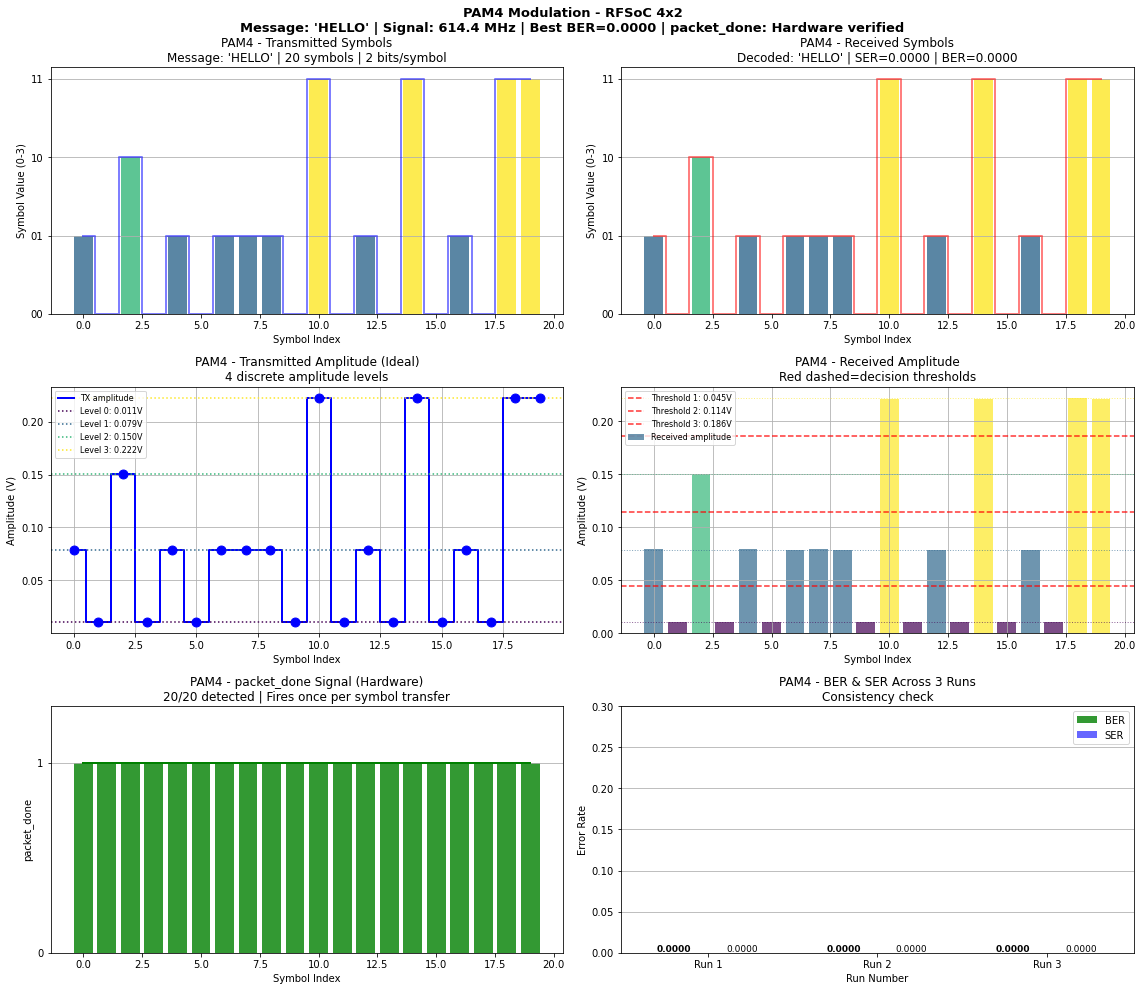


  PAM4 DETAILED TEST SUMMARY
  Message sent:    'HELLO'
  Best decoded:    'HELLO'
  Best BER:        0.0000
  Best SER:        0.0000
  Symbols sent:    20
  packet_done:     20/20
  Amp levels:      ['0.0107V', '0.0788V', '0.1500V', '0.2223V']
  Thresholds:      ['0.0447V', '0.1144V', '0.1862V']
  Min gap:         0.0447V


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── PAM4 Parameters ──────────────────────────────────────
mode_name    = "PAM4"
bits_per_sym = 2
n_levels     = 4
gain_levels  = [0, 85, 170, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

# Pad to multiple of bits_per_sym
while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

# Convert to symbols
symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating PAM4 levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Min gap:    {min([thresholds[i+1]-thresholds[i] for i in range(len(thresholds)-1)] + [thresholds[0]]):.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []
    tx_times     = []
    rx_times     = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        # Transmit
        gain = gain_levels[symbol]
        set_gain(gain)
        tx_times.append(sym_idx * HOLD_TIME)
        time.sleep(HOLD_TIME)

        # Receive
        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        rx_times.append(sym_idx * HOLD_TIME + HOLD_TIME/2)

        clear_packet_done()

    set_gain(255)

    # Decode
    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8)
        )
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'tx_times':     tx_times,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

# Use best run
best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))

# ─── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# ── Plot 1: Transmitted symbols ───────────────────────────
colors_sym = plt.cm.viridis(np.linspace(0, 1, n_levels))
tx_colors  = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.5)
axes[0, 0].set_title(f'PAM4 - Transmitted Symbols\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} symbols | "
                     f"{bits_per_sym} bits/symbol")
axes[0, 0].set_xlabel('Symbol Index')
axes[0, 0].set_ylabel('Symbol Value (0-3)')
axes[0, 0].set_yticks([0, 1, 2, 3])
axes[0, 0].set_yticklabels(['00', '01', '10', '11'])
axes[0, 0].grid(True, axis='y')

# ── Plot 2: Received symbols ───────────────────────────────
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.5)
axes[0, 1].set_title(f'PAM4 - Received Symbols\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Symbol Index')
axes[0, 1].set_ylabel('Symbol Value (0-3)')
axes[0, 1].set_yticks([0, 1, 2, 3])
axes[0, 1].set_yticklabels(['00', '01', '10', '11'])
axes[0, 1].grid(True, axis='y')

# ── Plot 3: Transmitted amplitude (ideal) ─────────────────
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid', label='TX amplitude')
axes[1, 0].scatter(t_axis, tx_amps_ideal, c='blue',
                   s=80, zorder=5)
for i, al in enumerate(amp_levels):
    axes[1, 0].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1.5,
                       label=f'Level {i}: {al:.3f}V')
axes[1, 0].set_title('PAM4 - Transmitted Amplitude (Ideal)\n'
                     '4 discrete amplitude levels')
axes[1, 0].set_xlabel('Symbol Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# ── Plot 4: Received amplitude with thresholds ────────────
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.7,
               label='Received amplitude')
for i, t in enumerate(thresholds):
    axes[1, 1].axhline(y=t, color='red', linestyle='--',
                       linewidth=1.5, alpha=0.8,
                       label=f'Threshold {i+1}: {t:.3f}V')
for i, al in enumerate(amp_levels):
    axes[1, 1].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1,
                       alpha=0.6)
axes[1, 1].set_title('PAM4 - Received Amplitude\n'
                     'Red dashed=decision thresholds')
axes[1, 1].set_xlabel('Symbol Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True)

# ── Plot 5: packet_done signal ────────────────────────────
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-', linewidth=2,
                where='mid')
axes[2, 0].set_title(f'PAM4 - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per symbol transfer')
axes[2, 0].set_xlabel('Symbol Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# ── Plot 6: BER across runs ───────────────────────────────
bers = [r['ber'] for r in all_run_results]
sers = [r['ser'] for r in all_run_results]
x    = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red'
                      for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange'
                      for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002,
                    f'{b:.4f}', ha='center',
                    fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002,
                    f'{s:.4f}', ha='center',
                    fontsize=9)
axes[2, 1].set_title(f'PAM4 - BER & SER Across {NUM_RUNS} Runs\n'
                     f'Consistency check')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'PAM4 Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam4_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary ──────────────────────────────────────────────
print("\n" + "="*55)
print("  PAM4 DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Symbols sent:    {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Amp levels:      {[f'{a:.4f}V' for a in amp_levels]}")
print(f"  Thresholds:      {[f'{t:.4f}V' for t in thresholds]}")
print(f"  Min gap:         {min([thresholds[i+1]-thresholds[i] for i in range(len(thresholds)-1)] + [thresholds[0]]):.4f}V")
print("="*55)

Message:  'HELLO'
Bits:     0100100001000101010011000100110001001111
Symbols:  [2, 2, 0, 4, 2, 5, 1, 4, 2, 3, 0, 4, 7, 4]
N symbols:14

Calibrating PAM8 levels...
  gain=  0 → amp=0.0024V
  gain= 36 → amp=0.0263V
  gain= 72 → amp=0.0514V
  gain=109 → amp=0.0773V
  gain=145 → amp=0.1026V
  gain=182 → amp=0.1276V
  gain=218 → amp=0.1531V
  gain=255 → amp=0.1782V

Thresholds: ['0.0144V', '0.0388V', '0.0643V', '0.0899V', '0.1151V', '0.1404V', '0.1657V']
Min gap:    0.0238V

Run 1/3...
  Decoded: 'HELLO ' | BER=0.0000 | SER=0.0000 | pd=14/14
Run 2/3...
  Decoded: 'HELLO ' | BER=0.0000 | SER=0.0000 | pd=14/14
Run 3/3...
  Decoded: 'HELLO ' | BER=0.0000 | SER=0.0000 | pd=14/14


/tmp/ipykernel_1512/919463234.py:239: UserWarning: Glyph 0 ( ) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1512/919463234.py:240: UserWarning: Glyph 0 ( ) missing from current font.
  plt.savefig('pam8_detailed.png', dpi=150, bbox_inches='tight')
/usr/local/share/pynq-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 0 ( ) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


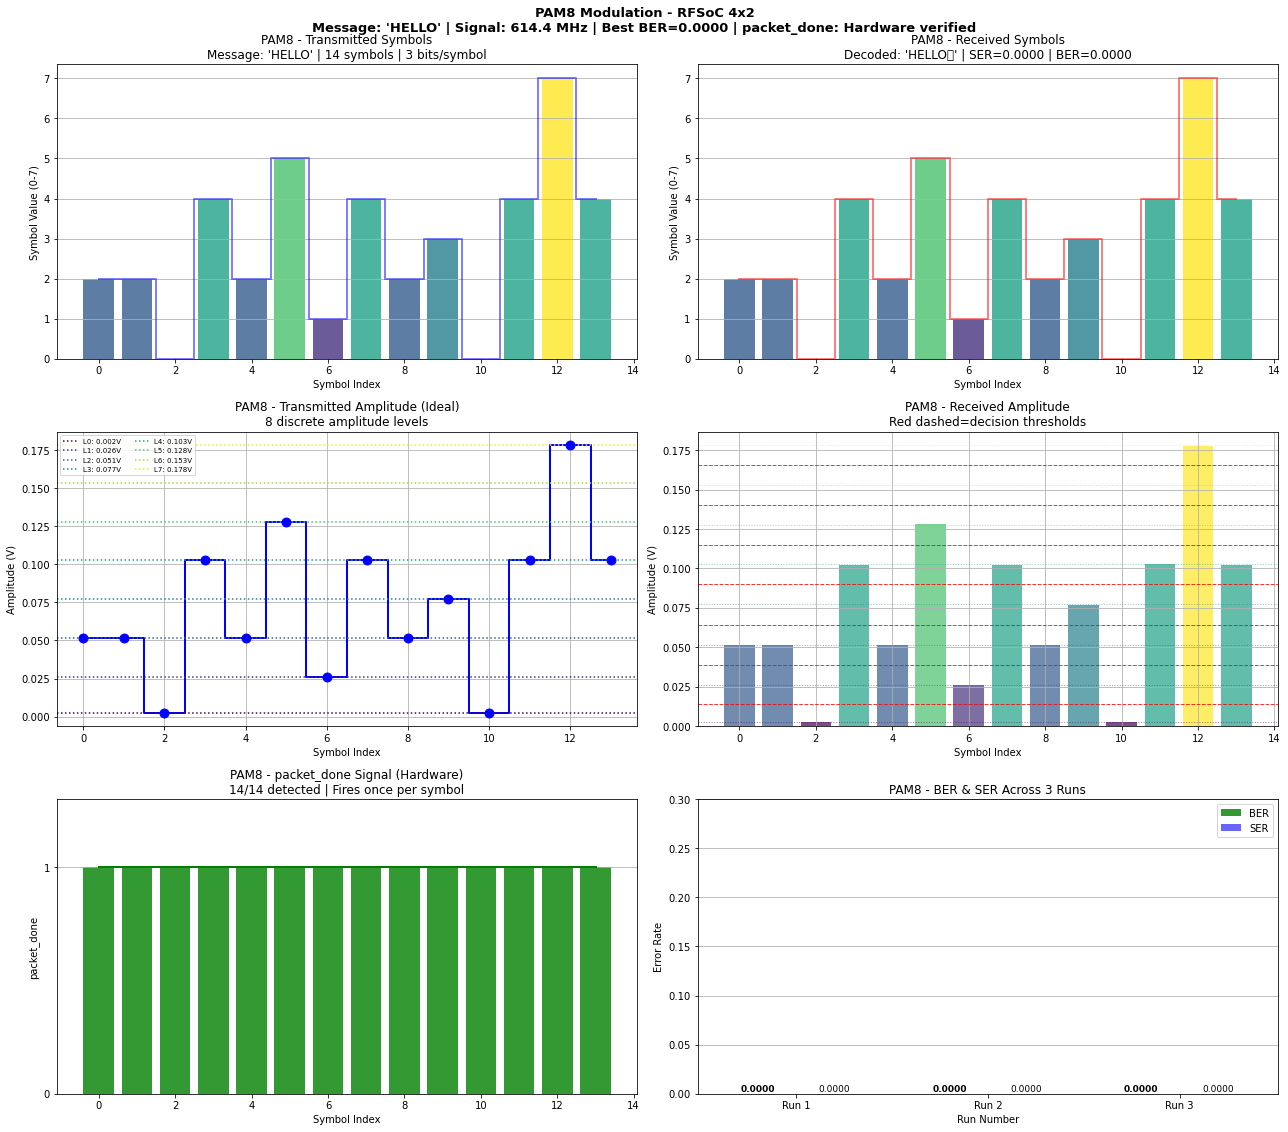


  PAM8 DETAILED TEST SUMMARY
  Message sent:    'HELLO'
  Best decoded:    'HELLO '
  Best BER:        0.0000
  Best SER:        0.0000
  Symbols sent:    14
  packet_done:     14/14
  Amp levels:      ['0.0024V', '0.0263V', '0.0514V', '0.0773V', '0.1026V', '0.1276V', '0.1531V', '0.1782V']
  Min gap:         0.0238V


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── PAM8 Parameters ──────────────────────────────────────
mode_name    = "PAM8"
bits_per_sym = 3
n_levels     = 8
gain_levels  = [0, 36, 72, 109, 145, 182, 218, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating PAM8 levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Min gap:    {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        gain = gain_levels[symbol]
        set_gain(gain)
        time.sleep(HOLD_TIME)

        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        clear_packet_done()

    set_gain(255)

    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8))
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))
bers     = [r['ber'] for r in all_run_results]
sers     = [r['ser'] for r in all_run_results]

# ─── Plot ─────────────────────────────────────────────────
colors_sym = plt.cm.viridis(np.linspace(0, 1, n_levels))
fig, axes  = plt.subplots(3, 2, figsize=(18, 16))

# Col 1: Transmitted symbols
tx_colors = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.5)
axes[0, 0].set_title(f'PAM8 - Transmitted Symbols\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} symbols | "
                     f"{bits_per_sym} bits/symbol")
axes[0, 0].set_xlabel('Symbol Index')
axes[0, 0].set_ylabel('Symbol Value (0-7)')
axes[0, 0].set_yticks(range(n_levels))
axes[0, 0].grid(True, axis='y')

# Col 2: Received symbols
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.5)
axes[0, 1].set_title(f'PAM8 - Received Symbols\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Symbol Index')
axes[0, 1].set_ylabel('Symbol Value (0-7)')
axes[0, 1].set_yticks(range(n_levels))
axes[0, 1].grid(True, axis='y')

# Col 3: Transmitted amplitude
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid')
axes[1, 0].scatter(t_axis, tx_amps_ideal,
                   c='blue', s=80, zorder=5)
for i, al in enumerate(amp_levels):
    axes[1, 0].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1.5,
                       label=f'L{i}: {al:.3f}V')
axes[1, 0].set_title('PAM8 - Transmitted Amplitude (Ideal)\n'
                     '8 discrete amplitude levels')
axes[1, 0].set_xlabel('Symbol Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 0].grid(True)

# Col 4: Received amplitude
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.7)
for t in thresholds:
    axes[1, 1].axhline(y=t, color='red',
                       linestyle='--', linewidth=1,
                       alpha=0.8)
for i, al in enumerate(amp_levels):
    axes[1, 1].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1,
                       alpha=0.5)
axes[1, 1].set_title('PAM8 - Received Amplitude\n'
                     'Red dashed=decision thresholds')
axes[1, 1].set_xlabel('Symbol Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].grid(True)

# Col 5: packet_done
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-',
                linewidth=2, where='mid')
axes[2, 0].set_title(f'PAM8 - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per symbol')
axes[2, 0].set_xlabel('Symbol Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# Col 6: BER across runs
x = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red' for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange' for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002, f'{b:.4f}',
                    ha='center', fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002, f'{s:.4f}',
                    ha='center', fontsize=9)
axes[2, 1].set_title(f'PAM8 - BER & SER Across {NUM_RUNS} Runs')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'PAM8 Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam8_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  PAM8 DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Symbols sent:    {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Amp levels:      {[f'{a:.4f}V' for a in amp_levels]}")
print(f"  Min gap:         {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V")
print("="*55)

Message:  'HELLO'
Bits:     0100100001000101010011000100110001001111
Symbols:  [4, 8, 4, 5, 4, 12, 4, 12, 4, 15]
N symbols:10

Calibrating PAM16 levels...
  gain=  0 → amp=0.0063V
  gain= 17 → amp=0.0148V
  gain= 34 → amp=0.0268V
  gain= 51 → amp=0.0384V
  gain= 68 → amp=0.0503V
  gain= 85 → amp=0.0623V
  gain=102 → amp=0.0739V
  gain=119 → amp=0.0859V
  gain=136 → amp=0.0980V
  gain=153 → amp=0.1092V
  gain=170 → amp=0.1213V
  gain=187 → amp=0.1326V
  gain=204 → amp=0.1443V
  gain=221 → amp=0.1567V
  gain=238 → amp=0.1678V
  gain=255 → amp=0.1796V

Thresholds: ['0.0106V', '0.0208V', '0.0326V', '0.0443V', '0.0563V', '0.0681V', '0.0799V', '0.0919V', '0.1036V', '0.1152V', '0.1269V', '0.1384V', '0.1505V', '0.1623V', '0.1737V']
Min gap:    0.0085V

Run 1/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=10/10
Run 2/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=10/10
Run 3/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=10/10


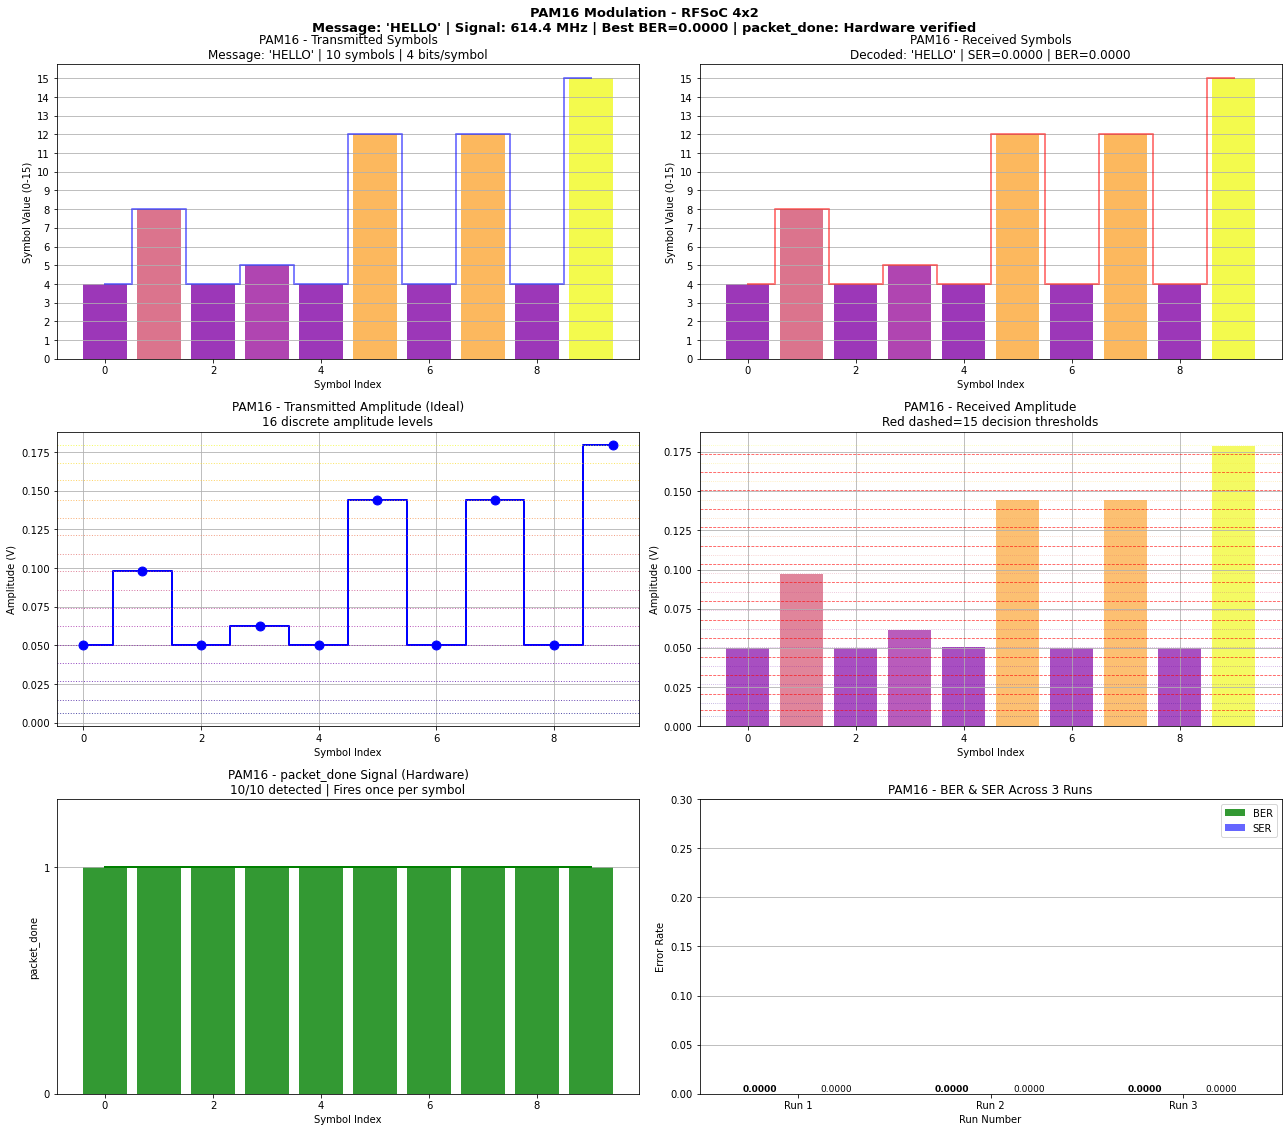


  PAM16 DETAILED TEST SUMMARY
  Message sent:    'HELLO'
  Best decoded:    'HELLO'
  Best BER:        0.0000
  Best SER:        0.0000
  Symbols sent:    10
  packet_done:     10/10
  Amp levels:      ['0.0063V', '0.0148V', '0.0268V', '0.0384V', '0.0503V', '0.0623V', '0.0739V', '0.0859V', '0.0980V', '0.1092V', '0.1213V', '0.1326V', '0.1443V', '0.1567V', '0.1678V', '0.1796V']
  Min gap:         0.0085V


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── PAM16 Parameters ─────────────────────────────────────
mode_name    = "PAM16"
bits_per_sym = 4
n_levels     = 16
gain_levels  = [0, 17, 34, 51, 68, 85, 102, 119,
                136, 153, 170, 187, 204, 221, 238, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating PAM16 levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Min gap:    {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        gain = gain_levels[symbol]
        set_gain(gain)
        time.sleep(HOLD_TIME)

        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        clear_packet_done()

    set_gain(255)

    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8))
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))
bers     = [r['ber'] for r in all_run_results]
sers     = [r['ser'] for r in all_run_results]

# ─── Plot ─────────────────────────────────────────────────
colors_sym = plt.cm.plasma(np.linspace(0, 1, n_levels))
fig, axes  = plt.subplots(3, 2, figsize=(18, 16))

# Col 1: Transmitted symbols
tx_colors = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.5)
axes[0, 0].set_title(f'PAM16 - Transmitted Symbols\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} symbols | "
                     f"{bits_per_sym} bits/symbol")
axes[0, 0].set_xlabel('Symbol Index')
axes[0, 0].set_ylabel('Symbol Value (0-15)')
axes[0, 0].set_yticks(range(n_levels))
axes[0, 0].grid(True, axis='y')

# Col 2: Received symbols
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.5)
axes[0, 1].set_title(f'PAM16 - Received Symbols\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Symbol Index')
axes[0, 1].set_ylabel('Symbol Value (0-15)')
axes[0, 1].set_yticks(range(n_levels))
axes[0, 1].grid(True, axis='y')

# Col 3: Transmitted amplitude
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid')
axes[1, 0].scatter(t_axis, tx_amps_ideal,
                   c='blue', s=80, zorder=5)
for i, al in enumerate(amp_levels):
    axes[1, 0].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=1,
                       alpha=0.7)
axes[1, 0].set_title('PAM16 - Transmitted Amplitude (Ideal)\n'
                     '16 discrete amplitude levels')
axes[1, 0].set_xlabel('Symbol Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].grid(True)

# Col 4: Received amplitude
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.7)
for t in thresholds:
    axes[1, 1].axhline(y=t, color='red',
                       linestyle='--', linewidth=0.8,
                       alpha=0.7)
for i, al in enumerate(amp_levels):
    axes[1, 1].axhline(y=al, color=colors_sym[i],
                       linestyle=':', linewidth=0.8,
                       alpha=0.4)
axes[1, 1].set_title('PAM16 - Received Amplitude\n'
                     'Red dashed=15 decision thresholds')
axes[1, 1].set_xlabel('Symbol Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].grid(True)

# Col 5: packet_done
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-',
                linewidth=2, where='mid')
axes[2, 0].set_title(f'PAM16 - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per symbol')
axes[2, 0].set_xlabel('Symbol Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# Col 6: BER across runs
x = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red' for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange' for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002, f'{b:.4f}',
                    ha='center', fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002, f'{s:.4f}',
                    ha='center', fontsize=9)
axes[2, 1].set_title(f'PAM16 - BER & SER Across {NUM_RUNS} Runs')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'PAM16 Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pam16_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  PAM16 DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Symbols sent:    {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Amp levels:      {[f'{a:.4f}V' for a in amp_levels]}")
print(f"  Min gap:         {min([amp_levels[i+1]-amp_levels[i] for i in range(len(amp_levels)-1)]):.4f}V")
print("="*55)

Message:  'HELLO'
Bits:     0100100001000101010011000100110001001111
Symbols:  [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]
N symbols:40

Calibrating NRZ levels...
  gain=  0 → amp=0.0086V
  gain=255 → amp=0.1814V

Thresholds: ['0.0950V']
Gap:        0.1728V

Run 1/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=40/40
Run 2/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=40/40
Run 3/3...
  Decoded: 'HELLO' | BER=0.0000 | SER=0.0000 | pd=40/40


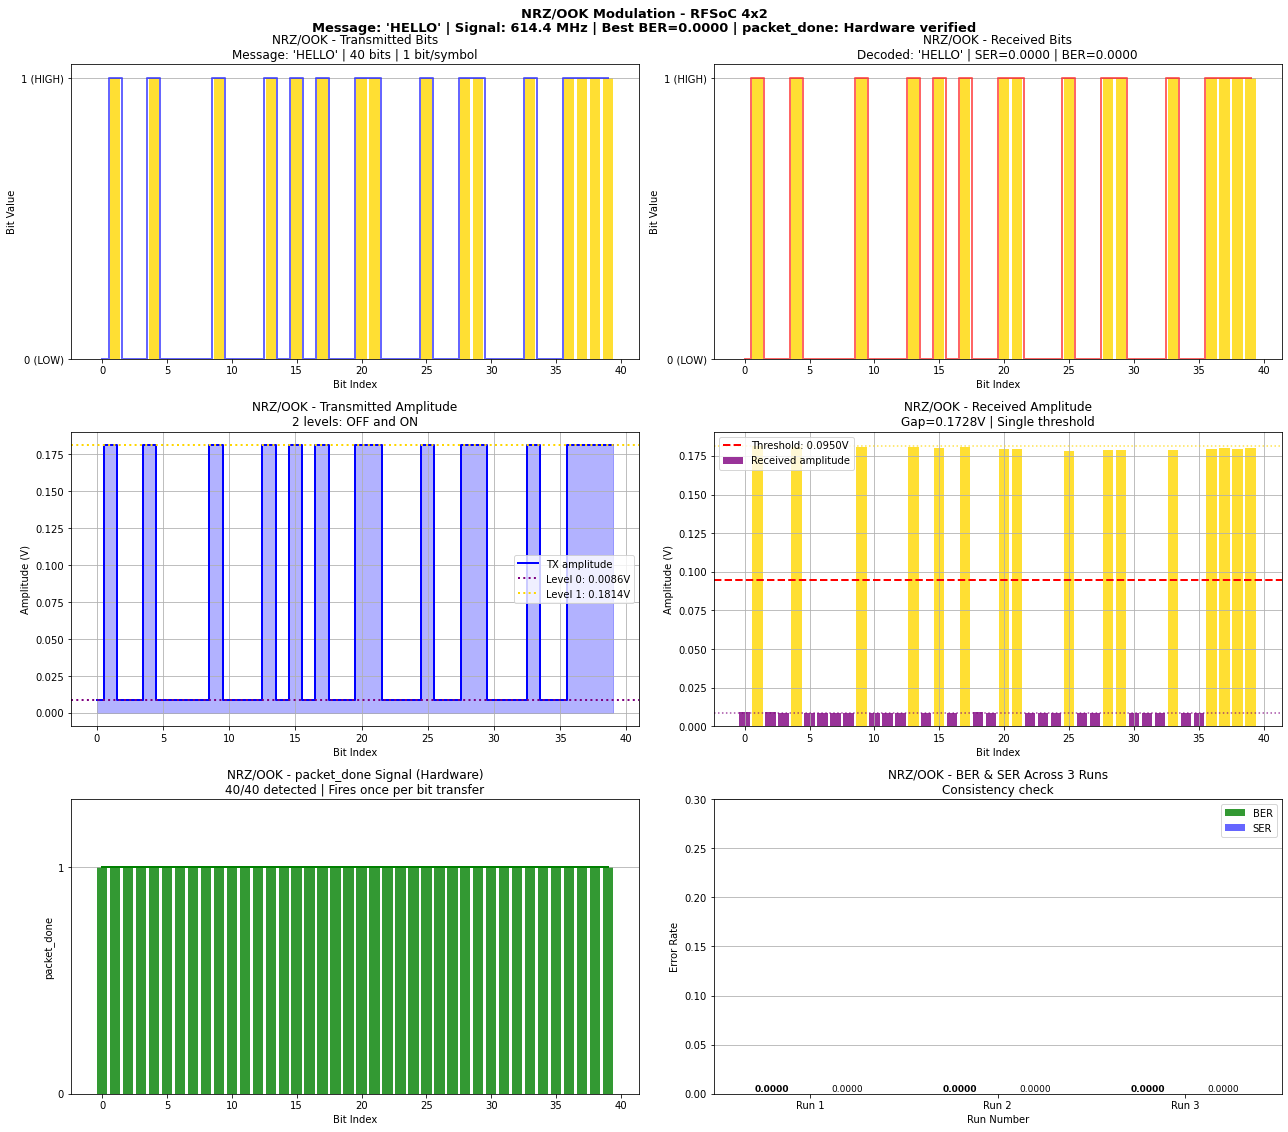


  NRZ/OOK DETAILED TEST SUMMARY
  Message sent:    'HELLO'
  Best decoded:    'HELLO'
  Best BER:        0.0000
  Best SER:        0.0000
  Bits sent:       40
  packet_done:     40/40
  Level HIGH:      0.1814V
  Level LOW:       0.0086V
  Gap:             0.1728V
  Threshold:       0.0950V


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─── NRZ/OOK Parameters ───────────────────────────────────
mode_name    = "NRZ/OOK"
bits_per_sym = 1
n_levels     = 2
gain_levels  = [0, 255]
HOLD_TIME    = 0.2
N            = 4096
fs           = 2457.6e6
NUM_RUNS     = 3

# ─── Message ──────────────────────────────────────────────
message  = "HELLO"
bits_msg = ''.join(format(ord(c), '08b') for c in message)
bit_list = [int(b) for b in bits_msg]

while len(bit_list) % bits_per_sym != 0:
    bit_list.append(0)

symbols = []
for i in range(0, len(bit_list), bits_per_sym):
    group = bit_list[i:i+bits_per_sym]
    symbols.append(int(''.join(str(b) for b in group), 2))

print(f"Message:  '{message}'")
print(f"Bits:     {bits_msg}")
print(f"Symbols:  {symbols}")
print(f"N symbols:{len(symbols)}\n")

# ─── Calibrate ────────────────────────────────────────────
print("Calibrating NRZ levels...")
amp_levels = []
for g in gain_levels:
    set_gain(g)
    time.sleep(0.3)
    received = ol.radio.receiver.channel[3].transfer(N)
    real_ac  = np.real(received) - np.mean(np.real(received))
    amp      = np.max(np.abs(real_ac))
    amp_levels.append(amp)
    print(f"  gain={g:3d} → amp={amp:.4f}V")

thresholds = [(amp_levels[i]+amp_levels[i+1])/2
              for i in range(len(amp_levels)-1)]
print(f"\nThresholds: {[f'{t:.4f}V' for t in thresholds]}")
print(f"Gap:        {amp_levels[1]-amp_levels[0]:.4f}V\n")

def decode_symbol(amp, thresholds):
    for i, t in enumerate(thresholds):
        if amp < t:
            return i
    return len(thresholds)

def symbols_to_bits(symbols, bps):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{bps}b')])
    return bits

# ─── Run Transmission ─────────────────────────────────────
all_run_results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}...")
    rx_symbols   = []
    rx_amps      = []
    packet_dones = []

    clear_packet_done()

    for sym_idx, symbol in enumerate(symbols):
        gain = gain_levels[symbol]
        set_gain(gain)
        time.sleep(HOLD_TIME)

        received = ol.radio.receiver.channel[3].transfer(N)
        pd       = read_packet_done()
        real_ac  = np.real(received) - np.mean(np.real(received))
        amp      = np.max(np.abs(real_ac))
        rx_sym   = decode_symbol(amp, thresholds)

        rx_symbols.append(rx_sym)
        rx_amps.append(amp)
        packet_dones.append(pd)
        clear_packet_done()

    set_gain(255)

    rx_bits     = symbols_to_bits(rx_symbols, bits_per_sym)
    rx_bits     = rx_bits[:len(bit_list)]
    rx_bits_str = ''.join(str(b) for b in rx_bits)
    try:
        rx_message = ''.join(
            chr(int(rx_bits_str[i:i+8], 2))
            for i in range(0, len(rx_bits_str), 8))
    except:
        rx_message = "error"

    sym_errors = sum(t != r for t, r in zip(symbols, rx_symbols))
    bit_errors = sum(t != r for t, r in zip(bit_list, rx_bits))
    ser        = sym_errors / len(symbols)
    ber        = bit_errors / len(bit_list)

    print(f"  Decoded: '{rx_message}' | "
          f"BER={ber:.4f} | SER={ser:.4f} | "
          f"pd={sum(packet_dones)}/{len(symbols)}")

    all_run_results.append({
        'symbols':      symbols,
        'rx_symbols':   rx_symbols,
        'rx_amps':      rx_amps,
        'packet_dones': packet_dones,
        'rx_message':   rx_message,
        'sym_errors':   sym_errors,
        'bit_errors':   bit_errors,
        'ser':          ser,
        'ber':          ber,
        'rx_bits':      rx_bits,
    })

best_run = min(all_run_results, key=lambda r: r['ber'])
n_sym    = len(symbols)
t_axis   = list(range(n_sym))
bers     = [r['ber'] for r in all_run_results]
sers     = [r['ser'] for r in all_run_results]

# ─── Plot ─────────────────────────────────────────────────
colors_sym = ['purple', 'gold']
fig, axes  = plt.subplots(3, 2, figsize=(18, 16))

# Col 1: Transmitted bits
tx_colors = [colors_sym[s] for s in symbols]
axes[0, 0].bar(t_axis, symbols, color=tx_colors, alpha=0.8)
axes[0, 0].step(t_axis, symbols, 'b-', linewidth=2,
                where='mid', alpha=0.6)
axes[0, 0].set_title(f'NRZ/OOK - Transmitted Bits\n'
                     f"Message: '{message}' | "
                     f"{len(symbols)} bits | "
                     f"1 bit/symbol")
axes[0, 0].set_xlabel('Bit Index')
axes[0, 0].set_ylabel('Bit Value')
axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_yticklabels(['0 (LOW)', '1 (HIGH)'])
axes[0, 0].grid(True, axis='y')

# Col 2: Received bits
rx_colors = [colors_sym[s] for s in best_run['rx_symbols']]
axes[0, 1].bar(t_axis, best_run['rx_symbols'],
               color=rx_colors, alpha=0.8)
axes[0, 1].step(t_axis, best_run['rx_symbols'], 'r-',
                linewidth=2, where='mid', alpha=0.6)
axes[0, 1].set_title(f'NRZ/OOK - Received Bits\n'
                     f"Decoded: '{best_run['rx_message']}' | "
                     f"SER={best_run['ser']:.4f} | "
                     f"BER={best_run['ber']:.4f}")
axes[0, 1].set_xlabel('Bit Index')
axes[0, 1].set_ylabel('Bit Value')
axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_yticklabels(['0 (LOW)', '1 (HIGH)'])
axes[0, 1].grid(True, axis='y')

# Col 3: Transmitted amplitude
tx_amps_ideal = [amp_levels[s] for s in symbols]
axes[1, 0].step(t_axis, tx_amps_ideal, 'b-',
                linewidth=2, where='mid',
                label='TX amplitude')
axes[1, 0].fill_between(t_axis, tx_amps_ideal,
                         step='mid', alpha=0.3, color='blue')
axes[1, 0].axhline(y=amp_levels[0], color='purple',
                   linestyle=':', linewidth=2,
                   label=f'Level 0: {amp_levels[0]:.4f}V')
axes[1, 0].axhline(y=amp_levels[1], color='gold',
                   linestyle=':', linewidth=2,
                   label=f'Level 1: {amp_levels[1]:.4f}V')
axes[1, 0].set_title('NRZ/OOK - Transmitted Amplitude\n'
                     '2 levels: OFF and ON')
axes[1, 0].set_xlabel('Bit Index')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Col 4: Received amplitude
bar_colors = [colors_sym[s] for s in symbols]
axes[1, 1].bar(t_axis, best_run['rx_amps'],
               color=bar_colors, alpha=0.8,
               label='Received amplitude')
axes[1, 1].axhline(y=thresholds[0], color='red',
                   linestyle='--', linewidth=2,
                   label=f'Threshold: {thresholds[0]:.4f}V')
axes[1, 1].axhline(y=amp_levels[0], color='purple',
                   linestyle=':', linewidth=1.5, alpha=0.7)
axes[1, 1].axhline(y=amp_levels[1], color='gold',
                   linestyle=':', linewidth=1.5, alpha=0.7)
axes[1, 1].set_title('NRZ/OOK - Received Amplitude\n'
                     f'Gap={amp_levels[1]-amp_levels[0]:.4f}V | '
                     f'Single threshold')
axes[1, 1].set_xlabel('Bit Index')
axes[1, 1].set_ylabel('Amplitude (V)')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Col 5: packet_done
pd_vals = best_run['packet_dones']
axes[2, 0].bar(t_axis, pd_vals, color='green', alpha=0.8)
axes[2, 0].step(t_axis, pd_vals, 'g-',
                linewidth=2, where='mid')
axes[2, 0].set_title(f'NRZ/OOK - packet_done Signal (Hardware)\n'
                     f'{sum(pd_vals)}/{n_sym} detected | '
                     f'Fires once per bit transfer')
axes[2, 0].set_xlabel('Bit Index')
axes[2, 0].set_ylabel('packet_done')
axes[2, 0].set_ylim([0, 1.3])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].grid(True, axis='y')

# Col 6: BER across runs
x = np.arange(NUM_RUNS)
axes[2, 1].bar(x - 0.2, bers, 0.35,
               color=['green' if b == 0 else 'red' for b in bers],
               alpha=0.8, label='BER')
axes[2, 1].bar(x + 0.2, sers, 0.35,
               color=['blue' if s == 0 else 'orange' for s in sers],
               alpha=0.6, label='SER')
for i, (b, s) in enumerate(zip(bers, sers)):
    axes[2, 1].text(i-0.2, b+0.002, f'{b:.4f}',
                    ha='center', fontsize=9, fontweight='bold')
    axes[2, 1].text(i+0.2, s+0.002, f'{s:.4f}',
                    ha='center', fontsize=9)
axes[2, 1].set_title(f'NRZ/OOK - BER & SER Across {NUM_RUNS} Runs\n'
                     f'Consistency check')
axes[2, 1].set_xlabel('Run Number')
axes[2, 1].set_ylabel('Error Rate')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels([f'Run {i+1}' for i in range(NUM_RUNS)])
axes[2, 1].set_ylim([0, 0.3])
axes[2, 1].legend()
axes[2, 1].grid(True, axis='y')

plt.suptitle(
    f'NRZ/OOK Modulation - RFSoC 4x2\n'
    f"Message: '{message}' | Signal: 614.4 MHz | "
    f"Best BER={min(bers):.4f} | "
    f"packet_done: Hardware verified",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nrz_ook_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  NRZ/OOK DETAILED TEST SUMMARY")
print("="*55)
print(f"  Message sent:    '{message}'")
print(f"  Best decoded:    '{best_run['rx_message']}'")
print(f"  Best BER:        {min(bers):.4f}")
print(f"  Best SER:        {min(sers):.4f}")
print(f"  Bits sent:       {len(symbols)}")
print(f"  packet_done:     {sum(best_run['packet_dones'])}/{len(symbols)}")
print(f"  Level HIGH:      {amp_levels[1]:.4f}V")
print(f"  Level LOW:       {amp_levels[0]:.4f}V")
print(f"  Gap:             {amp_levels[1]-amp_levels[0]:.4f}V")
print(f"  Threshold:       {thresholds[0]:.4f}V")
print("="*55)